# 🏦 Xóm Bank — Phase 5: Machine Learning Modeling & Business Cost Optimization

> **Mục tiêu:**
> 1. Trích xuất đặc trưng với bảo đảm **Feature Parity 100%** (`FraudFeatureEngineer`).
> 2. Đánh giá & so sánh 3 mô hình (**Logistic Regression**, **Random Forest**, **LightGBM**) qua **Stratified 5-Fold Cross-Validation**.
> 3. Tối ưu ngưỡng quyết định (Threshold Tuning) theo **Ma trận Chi phí Kinh doanh (Business Cost Matrix)** ($500 FN vs $15 FP).
> 4. Đánh giá trên tập kiểm thử tương lai **Temporal Hold-Out (`fraudTest.csv` — 555,719 giao dịch)**.
> 5. Trực quan hóa đường cong PR-AUC, Ma trận nhầm lẫn (Confusion Matrix), và Feature Importances.

In [2]:
import os
import sys
import time
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# Thêm project root vào sys.path
project_root = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from ml.feature_engineering import FraudFeatureEngineer, haversine_distance_km
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    average_precision_score, precision_recall_curve, roc_curve, roc_auc_score,
    f1_score, precision_score, recall_score, confusion_matrix, classification_report
)
import lightgbm as lgb

# Cấu hình plot đẹp mắt
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.figsize'] = (10, 6)
print('✅ Đã load toàn bộ thư viện & cấu hình môi trường thành công!')

✅ Đã load toàn bộ thư viện & cấu hình môi trường thành công!


## 1. Đọc Dữ liệu Huấn luyện & Kiểm thử (Train & Temporal Hold-out Test)

In [3]:
train_path = os.path.join(project_root, 'data', 'fraudTrain.csv')
test_path = os.path.join(project_root, 'data', 'fraudTest.csv')

# Để huấn luyện nhanh trong notebook ta có thể dùng sample 150k dòng hoặc toàn bộ dataset
sample_size = 150000
df_train = pd.read_csv(train_path, index_col=0, nrows=sample_size)
df_test = pd.read_csv(test_path, index_col=0)

print(f"Train sample shape: {df_train.shape[0]:,} rows × {df_train.shape[1]} cols")
print(f"Test holdout shape: {df_test.shape[0]:,} rows × {df_test.shape[1]} cols")
print(f"Train Fraud count:  {df_train['is_fraud'].sum():,} ({df_train['is_fraud'].mean()*100:.3f}%)")
print(f"Test Fraud count:   {df_test['is_fraud'].sum():,} ({df_test['is_fraud'].mean()*100:.3f}%)")

Train sample shape: 150,000 rows × 22 cols
Test holdout shape: 555,719 rows × 22 cols
Train Fraud count:  1,377 (0.918%)
Test Fraud count:   2,145 (0.386%)


## 2. Trích xuất Đặc trưng (Feature Engineering với Feature Parity)

In [4]:
fe = FraudFeatureEngineer().fit(df_train)
X_train, y_train = fe.transform_batch(df_train, is_training=True)
X_test, y_test = fe.transform_batch(df_test, is_training=False)

print(f"Feature matrix X_train: {X_train.shape}")
print(f"Feature matrix X_test:  {X_test.shape}")
print(f"Danh sách 27 đặc trưng:\n", list(X_train.columns))

[*] Fitting FraudFeatureEngineer customer baselines...
[+] Fitted profiles for 928 unique customers.
Feature matrix X_train: (150000, 27)
Feature matrix X_test:  (555719, 27)
Danh sách 27 đặc trưng:
 ['amt', 'amt_log', 'geo_distance_km', 'txn_freq_24h', 'amt_zscore_by_customer', 'trans_hour', 'day_of_week', 'is_weekend', 'is_night', 'customer_age', 'city_pop_log', 'gender_code', 'cat_entertainment', 'cat_food_dining', 'cat_gas_transport', 'cat_grocery_net', 'cat_grocery_pos', 'cat_health_fitness', 'cat_home', 'cat_kids_pets', 'cat_misc_net', 'cat_misc_pos', 'cat_personal_care', 'cat_shopping_net', 'cat_shopping_pos', 'cat_travel', 'cat_other']


## 3. Huấn luyện & So sánh 3 Mô hình qua Stratified 5-Fold Cross-Validation

In [5]:
fraud_cnt = int(np.sum(y_train))
imbalance_ratio = float((len(y_train) - fraud_cnt) / max(1, fraud_cnt))

models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42))
    ]),
    "Random Forest": RandomForestClassifier(
        n_estimators=100, max_depth=14, min_samples_split=10, min_samples_leaf=5,
        class_weight="balanced", random_state=42, n_jobs=-1
    ),
    "LightGBM": lgb.LGBMClassifier(
        n_estimators=150, learning_rate=0.05, num_leaves=31, max_depth=7,
        scale_pos_weight=imbalance_ratio, random_state=42, n_jobs=-1, verbosity=-1
    )
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}

for name, model in models.items():
    print(f"\n⏳ Đang cross-validate: {name}...")
    t0 = time.time()
    pr_aucs, roc_aucs = [], []
    for fold, (t_idx, v_idx) in enumerate(skf.split(X_train, y_train), start=1):
        X_tr, y_tr = X_train.iloc[t_idx], y_train[t_idx]
        X_va, y_va = X_train.iloc[v_idx], y_train[v_idx]
        model.fit(X_tr, y_tr)
        probs = model.predict_proba(X_va)[:, 1]
        pr_aucs.append(average_precision_score(y_va, probs))
        roc_aucs.append(roc_auc_score(y_va, probs))
    elapsed = time.time() - t0
    cv_results[name] = {
        'mean_pr_auc': np.mean(pr_aucs),
        'std_pr_auc': np.std(pr_aucs),
        'mean_roc_auc': np.mean(roc_aucs),
        'time': elapsed
    }
    print(f"   ==> {name} | PR-AUC: {np.mean(pr_aucs):.4f} (±{np.std(pr_aucs):.4f}) | ROC-AUC: {np.mean(roc_aucs):.4f} | Time: {elapsed:.1f}s")

pd.DataFrame(cv_results).T


⏳ Đang cross-validate: Logistic Regression...
   ==> Logistic Regression | PR-AUC: 0.3621 (±0.0313) | ROC-AUC: 0.9609 | Time: 1.4s

⏳ Đang cross-validate: Random Forest...
   ==> Random Forest | PR-AUC: 0.8946 (±0.0114) | ROC-AUC: 0.9961 | Time: 8.4s

⏳ Đang cross-validate: LightGBM...
   ==> LightGBM | PR-AUC: 0.9177 (±0.0115) | ROC-AUC: 0.9966 | Time: 2.5s


,mean_pr_auc,std_pr_auc,mean_roc_auc,time
Logistic Regression,0.362106,0.031337,0.960887,1.412617
Random Forest,0.894591,0.011382,0.996100,8.384236
LightGBM,0.917691,0.011522,0.996618,2.468284


## 4. Tối ưu Ngưỡng Quyết định theo Ma trận Chi phí Kinh doanh (Cost Matrix Optimization)

- **Chi phí bỏ lọt gian lận (False Negative):** $500
- **Chi phí chặn nhầm khách thật (False Positive):** $15

🎯 Optimal Decision Threshold: 0.7500
💰 Min Estimated Cost: $13,160.00


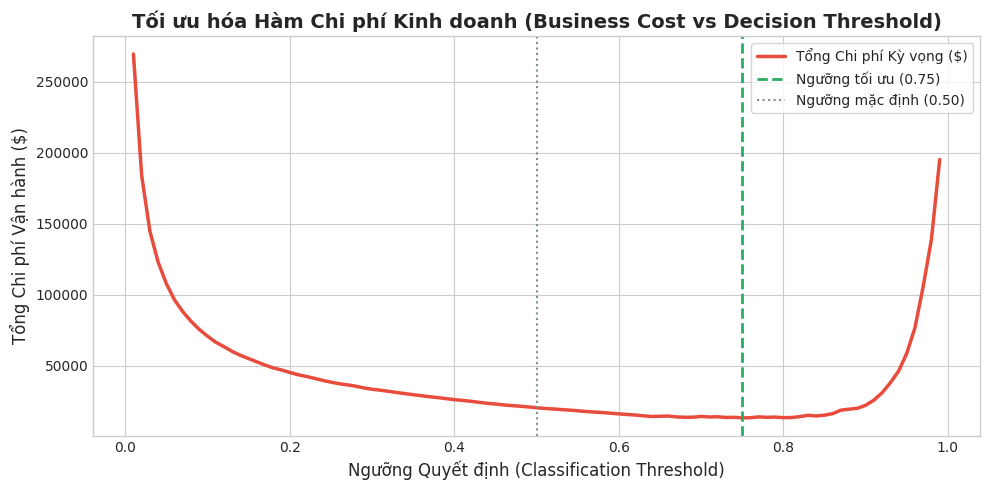

In [6]:
# Huấn luyện mô hình tốt nhất (LightGBM) trên toàn bộ tập train
best_model = models["LightGBM"]
best_model.fit(X_train, y_train)

train_probs = best_model.predict_proba(X_train)[:, 1]
thresholds = np.linspace(0.01, 0.99, 99)
cost_history = []
fn_cost = 500.0
fp_cost = 15.0

for t in thresholds:
    preds = (train_probs >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_train, preds, labels=[0, 1]).ravel()
    total_c = (fn * fn_cost) + (fp * fp_cost)
    cost_history.append(total_c)

opt_idx = np.argmin(cost_history)
optimal_threshold = thresholds[opt_idx]
min_cost = cost_history[opt_idx]

print(f"🎯 Optimal Decision Threshold: {optimal_threshold:.4f}")
print(f"💰 Min Estimated Cost: ${min_cost:,.2f}")

# Vẽ biểu đồ đường cong Chi phí Kinh doanh theo Ngưỡng
plt.figure(figsize=(10, 5))
plt.plot(thresholds, cost_history, color='#e74c3c', lw=2.5, label='Tổng Chi phí Kỳ vọng ($)')
plt.axvline(optimal_threshold, color='#27ae60', linestyle='--', lw=2, label=f'Ngưỡng tối ưu ({optimal_threshold:.2f})')
plt.axvline(0.5, color='#7f8c8d', linestyle=':', lw=1.5, label='Ngưỡng mặc định (0.50)')
plt.title('Tối ưu hóa Hàm Chi phí Kinh doanh (Business Cost vs Decision Threshold)', fontsize=14, fontweight='bold')
plt.xlabel('Ngưỡng Quyết định (Classification Threshold)', fontsize=12)
plt.ylabel('Tổng Chi phí Vận hành ($)', fontsize=12)
plt.legend(frameon=True)
plt.tight_layout()
plt.show()

## 5. Đánh giá trên Tập Kiểm thử Tương lai (Temporal Hold-Out Test Set: 555,719 dòng)

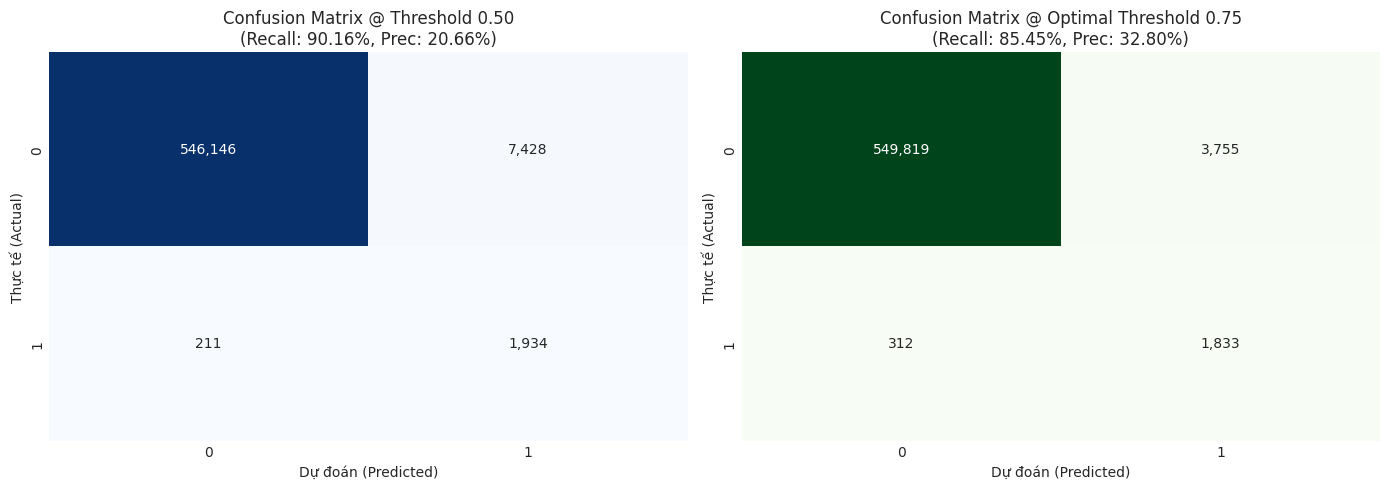

In [7]:
test_probs = best_model.predict_proba(X_test)[:, 1]
test_pr_auc = average_precision_score(y_test, test_probs)
test_roc_auc = roc_auc_score(y_test, test_probs)

# Đánh giá tại ngưỡng 0.5 vs 0.75
preds_def = (test_probs >= 0.5).astype(int)
preds_opt = (test_probs >= optimal_threshold).astype(int)

cm_def = confusion_matrix(y_test, preds_def, labels=[0, 1])
cm_opt = confusion_matrix(y_test, preds_opt, labels=[0, 1])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(cm_def, annot=True, fmt=',d', cmap='Blues', ax=axes[0], cbar=False)
axes[0].set_title(f'Confusion Matrix @ Threshold 0.50\n(Recall: {recall_score(y_test, preds_def)*100:.2f}%, Prec: {precision_score(y_test, preds_def)*100:.2f}%)', fontsize=12)
axes[0].set_xlabel('Dự đoán (Predicted)')
axes[0].set_ylabel('Thực tế (Actual)')

sns.heatmap(cm_opt, annot=True, fmt=',d', cmap='Greens', ax=axes[1], cbar=False)
axes[1].set_title(f'Confusion Matrix @ Optimal Threshold {optimal_threshold:.2f}\n(Recall: {recall_score(y_test, preds_opt)*100:.2f}%, Prec: {precision_score(y_test, preds_opt)*100:.2f}%)', fontsize=12)
axes[1].set_xlabel('Dự đoán (Predicted)')
axes[1].set_ylabel('Thực tế (Actual)')

plt.tight_layout()
plt.show()

## 6. Trực quan hóa Đường cong Precision-Recall & Feature Importances

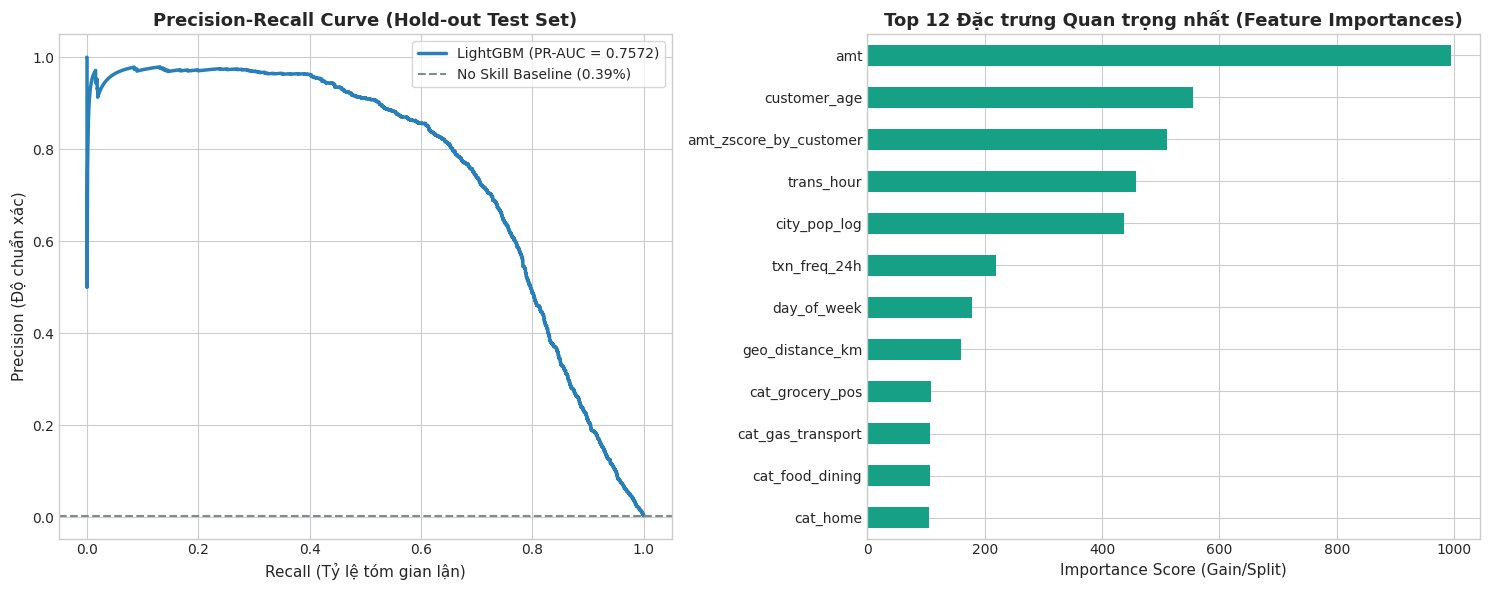

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 1. Precision-Recall Curve
precisions, recalls, _ = precision_recall_curve(y_test, test_probs)
axes[0].plot(recalls, precisions, color='#2980b9', lw=2.5, label=f'LightGBM (PR-AUC = {test_pr_auc:.4f})')
axes[0].axhline(y_test.mean(), color='#7f8c8d', linestyle='--', label=f'No Skill Baseline ({y_test.mean()*100:.2f}%)')
axes[0].set_title('Precision-Recall Curve (Hold-out Test Set)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Recall (Tỷ lệ tóm gian lận)', fontsize=11)
axes[0].set_ylabel('Precision (Độ chuẩn xác)', fontsize=11)
axes[0].legend(frameon=True)

# 2. Feature Importances
importances = pd.Series(best_model.feature_importances_, index=X_train.columns).sort_values(ascending=True).tail(12)
importances.plot(kind='barh', color='#16a085', ax=axes[1])
axes[1].set_title('Top 12 Đặc trưng Quan trọng nhất (Feature Importances)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Importance Score (Gain/Split)', fontsize=11)

plt.tight_layout()
plt.show()

## 7. Xuất xưởng Model Artifacts cho Hệ thống Phục vụ Thời gian thực (Phase 6)

In [9]:
models_dir = os.path.join(project_root, 'ml', 'models')
os.makedirs(models_dir, exist_ok=True)

model_path = os.path.join(models_dir, 'best_fraud_model.joblib')
fe_path = os.path.join(models_dir, 'feature_engineer.joblib')

joblib.dump(best_model, model_path)
joblib.dump(fe, fe_path)

print(f"💾 Đã lưu Production Model:     {model_path}")
print(f"💾 Đã lưu Feature Transformer:  {fe_path}")
print("🎉 PHASE 5 MODEL TRAINING HOÀN TẤT THÀNH CÔNG!")

💾 Đã lưu Production Model:     c:\Users\Dell\Desktop\Project3\ml\models\best_fraud_model.joblib
💾 Đã lưu Feature Transformer:  c:\Users\Dell\Desktop\Project3\ml\models\feature_engineer.joblib
🎉 PHASE 5 MODEL TRAINING HOÀN TẤT THÀNH CÔNG!
